In [83]:
import jax.numpy as jnp
import jax.random as jr
import jax
import matplotlib.pyplot as plt
import jax.scipy.linalg as linalg

from rk45_solver import rk45
import importlib
import animation
importlib.reload(animation)
import animation_double
importlib.reload(animation_double)
from jax.experimental.ode import odeint

from IPython.display import HTML
from functools import partial

# System definition

In [2]:
def rhs(y, t, PENDULUM_MASS, CART_MASS, LEN, GAMMA, FORCE):
    GRAVITY = 9.81

    x = y[0]
    theta = y[1]
    v = y[2]
    omega = y[3]

    v_dot = (FORCE - GAMMA * v + (GRAVITY * jnp.jnp.jnp.cos(theta) - LEN * omega**2) * PENDULUM_MASS * jnp.jnp.sin(theta)) / (CART_MASS + PENDULUM_MASS * jnp.jnp.sin(theta)**2)
    omega_dot = ((FORCE - GAMMA * v) * jnp.cos(theta) + GRAVITY * CART_MASS * jnp.jnp.sin(theta) + (GRAVITY - LEN * jnp.jnp.cos(theta) * omega**2) * PENDULUM_MASS * jnp.jnp.sin(theta)) / (LEN * (CART_MASS + PENDULUM_MASS * jnp.jnp.sin(theta)**2))

    return jnp.array([v, omega, v_dot, omega_dot])

# Loss function

The algorithm will seek to minimise the following function ujnp.sing a stochastic gradient descent method.

In [73]:
def loss(F, y, step, args):
    soln = odeint(rhs, y, step, *args.values(), F)
    x, theta, v, omega = soln[-1]

    return theta**2

grad_loss = jax.grad(loss, argnums=0)

In [96]:
args = {
    'PENDULUM_MASS': 0.1,
    'CART_MASS': 1.,
    'LEN': 1.,
    'GAMMA': 1.
}

rate = 50_000

ts = jnp.linspace(0, 15, 300)
rolled_ts = jnp.roll(ts, -1)
pairs = jnp.stack((ts, rolled_ts), axis=1)[:-1]

y0 = jnp.array([0, 0.5 * jnp.pi, 0, 0], dtype=jnp.float32)
F0 = 0.

key = jr.PRNGKey(42)

def scan_fun(carry, pair):
    y, F, key = carry
    # rate = rate_factor * loss(F, y, pair, args) / 0.015
    def body_fun(i, fori_carry):
        F, key = fori_carry
        key, new_key = jr.split(key)
        grad = grad_loss(F, y, pair, args)
        # sign = jnp.sign()
        F -= rate * grad - y[2] * jnp.abs(jr.normal(new_key)) * args['CART_MASS']
        F = jax.lax.cond(pair[1] < 0.5, lambda F: 0., lambda F: F, F)
        # pot = 9.81 * args['PENDULUM_MASS'] * args['LEN'] * jnp.jnp.cos(y[1])
        # rot = args['CART_MASS'] * args['LEN']**2 * y[3]**2
        # F = jax.lax.cond(jnp.abs(F) < 400, lambda F: F, lambda F: jnp.sign(F) * 400, F)

        return jnp.clip(F, -100 * args['LEN'] * args['CART_MASS'], 100 * args['LEN'] * args['CART_MASS']), key

    fori_carry = F, key
    F, key = jax.lax.fori_loop(0, 10, body_fun, fori_carry)
    y = odeint(rhs, y, pair, *args.values(), F)
    carry = y[1], F, key

    return carry, (y[1], F)


init_carry = y0, F0, key
carry, (ys, Fs) = jax.lax.scan(scan_fun, init_carry, pairs)

Fs = jnp.insert(Fs, 0, F0)
ys = jnp.insert(ys.flatten(), 0, y0)
ys = ys.reshape(ts.size, 4)

In [97]:
%matplotlib notebook
anim = animation.animate_pendulum(ts, ys, 1., rolling_ax=True)
plt.close()

HTML(anim.to_jshtml())

<IPython.core.display.Javascript object>

In [109]:
args = {
    'PENDULUM_MASS': 0.1,
    'CART_MASS': 1.,
    'LEN': 1.,
    'GAMMA': 1.
}

rate = 50_000

ts = jnp.linspace(0, 15, 300)
rolled_ts = jnp.roll(ts, -1)
pairs = jnp.stack((ts, rolled_ts), axis=1)[:-1]

y0 = jnp.array([0, jnp.pi, 0, 0], dtype=jnp.float32)
F0 = 0.

key = jr.PRNGKey(42)

def scan_fun(carry, pair):
    y, F, key = carry
    # rate = rate_factor * loss(F, y, pair, args) / 0.015
    def body_fun(i, fori_carry):
        F, key = fori_carry
        key, new_key = jr.split(key)
        grad = grad_loss(F, y, pair, args)
        # sign = jnp.sign()
        F -= rate * grad - y[2] * jnp.abs(jr.normal(new_key)) * args['CART_MASS']
        # F = jax.lax.cond(pair[1] < 0.5, lambda F: 0., lambda F: F, F)
        # pot = 9.81 * args['PENDULUM_MASS'] * args['LEN'] * jnp.jnp.cos(y[1])
        # rot = args['CART_MASS'] * args['LEN']**2 * y[3]**2
        # F = jax.lax.cond(jnp.abs(F) < 400, lambda F: F, lambda F: jnp.sign(F) * 400, F)

        return jnp.clip(F, -100, 100), key

    fori_carry = F, key
    F, key = jax.lax.fori_loop(0, 10, body_fun, fori_carry)
    y = odeint(rhs, y, pair, *args.values(), F)
    carry = y[1], F, key

    return carry, (y[1], F)


init_carry = y0, F0, key
carry, (ys, Fs) = jax.lax.scan(scan_fun, init_carry, pairs)

Fs = jnp.insert(Fs, 0, F0)
ys = jnp.insert(ys.flatten(), 0, y0)
ys = ys.reshape(ts.size, 4)

In [110]:
%matplotlib notebook
anim = animation.animate_pendulum(ts, ys, 1., rolling_ax=True)
plt.close()

HTML(anim.to_jshtml())

<IPython.core.display.Javascript object>

# Double Pendulum

In [97]:
def rhs_double(ys, ts, args, F):
    g = 9.82
    M, m1, m2, l1, l2 = args.values()
    x, theta1, theta2, v, omega1, omega2 = ys

    a0 = M + m1 + m2
    a1 = (m2 + 2 * m1) * l1**2
    a2 = 2 * m2 * l1**2
    a3 = m2 * l1 * l2
    b1 = (m1 * l1 + m2 * l1) * g
    b2 = m2 * l2 * g

    inv_inertial_matrix_act = linalg.inv(jnp.array([[a0, b1*jnp.cos(theta1)/g, b2*jnp.cos(theta2)/g],
    [b1*jnp.cos(theta1)/g, a1, a3*jnp.cos(theta1 - theta2)], 
    [b2*jnp.cos(theta2)/g, a3*jnp.cos(theta1 - theta2), a2]]))
    C = jnp.array([[0, -b1*omega1*jnp.sin(theta1)/g, -b2*omega2*jnp.sin(theta2)/g],
    [0, 0, a3*omega2*jnp.sin(theta1-theta2)], [0, -a3*omega1*jnp.sin(theta1-theta2), 0]])
    G = jnp.array([0, -b1*jnp.sin(theta1), -b2*jnp.sin(theta2)])
    B = jnp.array([F, 0, 0])
    q_dot = jnp.array([v, omega1, omega2])

    rhs = inv_inertial_matrix_act @ (B - C @ q_dot - G)

    return jnp.array([v, omega1, omega2, *rhs])

In [132]:
args = {
    'CART_MASS': 30.,
    'PENDULUM_MASS_BOTTOM': 1.,
    'PENDULUM_MASS_TOP': 1.,
    'LEN_BOTTOM': 1.,
    'LEN_TOP': 1.
}

ys0 = jnp.array([0, 0.0 * jnp.pi, 0.6 * jnp.pi, 0, 0, 0], dtype=jnp.float32)
ts = jnp.linspace(0, 10, 200)
F = 0.

ys = odeint(rhs_double, ys0, ts, args, F)

In [96]:
anim = animation_double.animate_double_pendulum(ts, ys, 1., 1., True)
plt.close()
HTML(anim.to_jshtml())

In [146]:
def loss_double(F, y, step, args):
    soln = odeint(rhs_double, y, step, args, F)
    x, theta1, theta2, v, omega1, omega2 = soln[-1]

    return theta1**2 + theta2**2

grad_loss_double = jax.grad(loss_double, argnums=0)

In [157]:
rate = 50_000

ts = jnp.linspace(0, 5, 100)
rolled_ts = jnp.roll(ts, -1)
pairs = jnp.stack((ts, rolled_ts), axis=1)[:-1]

y0 = jnp.array([0, 0.001 * jnp.pi, 0 * jnp.pi, 0, 0, 0], dtype=jnp.float32)
F0 = 0.

key = jr.PRNGKey(42)

def scan_fun(carry, pair):
    y, F, key = carry
    def body_fun(i, fori_carry):
        F, key = fori_carry
        key, new_key = jr.split(key)
        grad = grad_loss_double(F, y, pair, args)
        F -= rate * grad  #- y[2] * jnp.abs(jr.normal(new_key)) * args['CART_MASS']
        #F = jax.lax.cond(pair[1] < 0.5, lambda F: 0., lambda F: F, F)

        return F, key#jnp.clip(F, -100 * args['LEN'] * args['CART_MASS'], 100 * args['LEN'] * args['CART_MASS']), key

    fori_carry = F, key
    F, key = jax.lax.fori_loop(0, 10, body_fun, fori_carry)
    y = odeint(rhs_double, y, pair, args, F)
    carry = y[1], F, key

    return carry, (y[1], F)


init_carry = y0, F0, key
carry, (ys, Fs) = jax.lax.scan(scan_fun, init_carry, pairs)

Fs = jnp.insert(Fs, 0, F0)
ys = jnp.insert(ys.flatten(), 0, y0)
ys = ys.reshape(ts.size, 6)

In [158]:
anim = animation_double.animate_double_pendulum(ts, ys, 1., 1., True)
plt.close()
HTML(anim.to_jshtml())

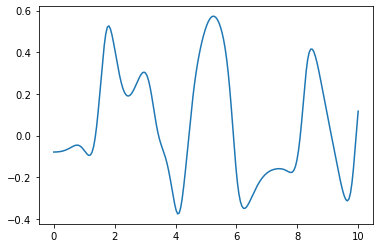

In [86]:
x, theta1, theta2, *_ = ys.T
M, m1, m2, l1, l2, *_ = args.values()

mass_mid = (M * x + m1 * (x - l1 * jnp.sin(theta1)) + m2 * (x - l1 * jnp.sin(theta1) - l2 * jnp.sin(theta2))) / (M + m1 + m2)
plt.plot(ts, mass_mid)

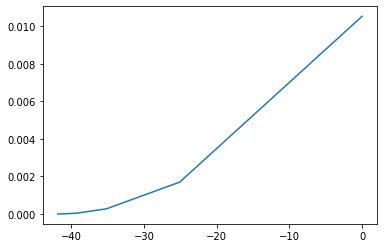

In [108]:
y0 = jnp.array([0, 0.1, 0, 0], dtype=jnp.float32)
ts = jnp.array([0, 0.07])
F0 = 0

rate = 50_000
amount = 10
fig, ax = plt.subplots()

Fs = jnp.zeros(amount)
Fs = Fs.at[0].set(F0)

for i in range(amount):
    F = Fs[i]
    grad = grad_loss(F, y0, ts, args)
    F -= rate * grad
    Fs = Fs.at[i + 1].set(F)

loss_vals = [loss(F, y0, ts, args) for F in Fs]

plt.plot(Fs, loss_vals)


In [85]:
from tqdm import tqdm

args = {
    'PENDULUM_MASS': 0.1,
    'CART_MASS': 1.,
    'LEN': 1.,
    'GAMMA': 1.
}

y = jnp.array([1., jnp.pi, 10., 0.])

Fs = jnp.linspace(-100, 100, 100)

loss_vals = jnp.empty(Fs.size)

for i, F in enumerate(tqdm(Fs)):
    val = loss(F, y, jnp.array([0., 0.5]), args)
    loss_vals = loss_vals.at[i].set(val)

100%|██████████| 100/100 [00:00<00:00, 140.64it/s]


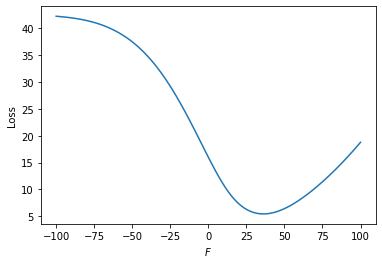

In [86]:
%matplotlib inline
plt.plot(Fs, loss_vals)
plt.xlabel('$F$')
plt.ylabel('Loss')
plt.show()